# Título: Análisis descriptivo con segmentación temporal

### Installs

In [1]:
# %pip install seaborn

### Imports

In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("data_cleaning_2026_20_04.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 706 entries, 0 to 705
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       706 non-null    int64  
 1   Reason_absence           706 non-null    int64  
 2   Month_absence            703 non-null    float64
 3   Day_week                 706 non-null    object 
 4   Seasons                  706 non-null    object 
 5   Transportation_expense   706 non-null    int64  
 6   Distance_Residence_Work  706 non-null    int64  
 7   Service_time             706 non-null    int64  
 8   Age                      706 non-null    int64  
 9   Work_load_Average_day    706 non-null    float64
 10  Hit_target               706 non-null    int64  
 11  Disciplinary_failure     706 non-null    int64  
 12  Education                706 non-null    int64  
 13  Son                      706 non-null    int64  
 14  Social_drinker           7

Transformación y reducción de datos

In [5]:
df_clean = df.loc[:, ~df.columns.isin(['Pet', 'Weight', 'Height'])]


In [6]:
df_clean['Month_absence'].unique()

array([11.,  4.,  7.,  3.,  6., 12., 10.,  5.,  8.,  9.,  1.,  2., nan])

In [7]:
df_clean['Month_absence'] = df_clean['Month_absence'].astype('Int64')
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 706 entries, 0 to 705
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       706 non-null    int64  
 1   Reason_absence           706 non-null    int64  
 2   Month_absence            703 non-null    Int64  
 3   Day_week                 706 non-null    object 
 4   Seasons                  706 non-null    object 
 5   Transportation_expense   706 non-null    int64  
 6   Distance_Residence_Work  706 non-null    int64  
 7   Service_time             706 non-null    int64  
 8   Age                      706 non-null    int64  
 9   Work_load_Average_day    706 non-null    float64
 10  Hit_target               706 non-null    int64  
 11  Disciplinary_failure     706 non-null    int64  
 12  Education                706 non-null    int64  
 13  Son                      706 non-null    int64  
 14  Social_drinker           7

C:\Users\acaro\AppData\Local\Temp\ipykernel_29616\2354035266.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Month_absence'] = df_clean['Month_absence'].astype('Int64')


In [8]:
df_clean[df_clean['Absenteeism_hours'] == 0]

,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,...,Education,Son,Social_drinker,Social_smoker,Body_mass_index,Absenteeism_hours,Disease_flag,Reason_absence_mapped,Month_absence_mapped,Education_mapped
662,36,0,7,Tuesday,summer,118,13,18,50,239.554,...,1,1,1,0,31,0,NaN,NaN,July,high_school
663,20,0,9,Monday,spring,260,50,11,36,241.476,...,1,4,1,0,23,0,NaN,NaN,September,high_school
664,29,0,9,Monday,spring,225,26,9,28,241.476,...,1,1,0,0,24,0,NaN,NaN,September,high_school
665,11,0,9,Tuesday,spring,289,36,13,33,241.476,...,1,2,1,0,30,0,NaN,NaN,September,high_school
666,36,0,9,Tuesday,spring,118,13,18,50,241.476,...,1,1,1,0,31,0,NaN,NaN,September,high_school
667,13,0,9,Wednesday,spring,369,17,12,31,241.476,...,1,3,1,0,25,0,NaN,NaN,September,high_school
668,36,0,10,Wednesday,spring,118,13,18,50,253.465,...,1,1,1,0,31,0,NaN,NaN,October,high_school
669,34,27,1,Monday,autumn,118,10,10,37,308.593,...,1,0,0,0,28,0,Not disease,Physiotherapy,January,high_school
670,2,0,4,Monday,winter,235,29,12,48,326.452,...,1,1,0,1,33,0,NaN,NaN,April,high_school
671,7,0,5,Wednesday,winter,279,5,14,39,378.884,...,1,2,1,1,24,0,NaN,NaN,May,high_school


In [9]:
df_clean[df_clean['Month_absence'].isna()]

,ID,Reason_absence,Month_absence,Day_week,Seasons,Transportation_expense,Distance_Residence_Work,Service_time,Age,Work_load_Average_day,...,Education,Son,Social_drinker,Social_smoker,Body_mass_index,Absenteeism_hours,Disease_flag,Reason_absence_mapped,Month_absence_mapped,Education_mapped
703,4,0,<NA>,Tuesday,summer,118,14,13,40,271.219,...,1,1,1,0,34,0,NaN,NaN,NaN,high_school
704,8,0,<NA>,Wednesday,autumn,231,35,14,39,271.219,...,1,2,1,0,35,0,NaN,NaN,NaN,high_school
705,35,0,<NA>,Friday,winter,179,45,14,53,271.219,...,1,1,0,0,25,0,NaN,NaN,NaN,high_school


Decidimos quitar los valores faltante por el tipo de datos, al no representar un ausencia real por el tipo de dataset.    

In [10]:
df_clean = df_clean[df_clean['Absenteeism_hours'] > 0]
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 662 entries, 0 to 661
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       662 non-null    int64  
 1   Reason_absence           662 non-null    int64  
 2   Month_absence            662 non-null    Int64  
 3   Day_week                 662 non-null    object 
 4   Seasons                  662 non-null    object 
 5   Transportation_expense   662 non-null    int64  
 6   Distance_Residence_Work  662 non-null    int64  
 7   Service_time             662 non-null    int64  
 8   Age                      662 non-null    int64  
 9   Work_load_Average_day    662 non-null    float64
 10  Hit_target               662 non-null    int64  
 11  Disciplinary_failure     662 non-null    int64  
 12  Education                662 non-null    int64  
 13  Son                      662 non-null    int64  
 14  Social_drinker           662 no

In [11]:
df_clean.to_csv("data_transformation_2026_22_04.csv", index=False, encoding="utf-8")

### Magnitud  del ausentísmo

In [12]:
df_clean['Absenteeism_hours'].describe()

count    662.000000
mean       7.617825
std       13.924277
min        1.000000
25%        2.000000
50%        4.000000
75%        8.000000
max      120.000000
Name: Absenteeism_hours, dtype: float64

In [26]:
tot_hours_ausent = df_clean['Absenteeism_hours'].sum()
print(f"Total hours of absenteeism: {tot_hours_ausent}")

""" asumiendo que son 36 empleados con 40 horas semanales, 52 semanas y 22 dias feriados. Calculamos el total de horas laborales al año y luego el porcentaje de horas ausentes """

total_employees = 36
hours_per_week = 40
weeks_per_year = 52
holidays_per_year = 22
total_working_hours_per_year = (hours_per_week * weeks_per_year - holidays_per_year * hours_per_week / 5) * total_employees
percentage_absent = (tot_hours_ausent / total_working_hours_per_year) * 100
print(f"Percentage of hours absent: {percentage_absent:.2f}%")

Total hours of absenteeism: 5043
Percentage of hours absent: 7.36%


In [30]:
def classify_hours(h):
    if pd.isna(h):
        return np.nan
    if h <= 4:
        return 'Very Short (0-4h)'
    if h <= 8:
        return 'Short (<8h)'
    elif h <= 24:
        return 'Medium (8-24h)'
    else:
        return 'Long (>24h)'

df['Absenteeism_terms'] = df['Absenteeism_hours'].apply(classify_hours)

print(df['Absenteeism_terms'].value_counts(dropna=False))

Absenteeism_terms
Very Short (0-4h)    428
Short (<8h)          215
Medium (8-24h)        35
Long (>24h)           28
Name: count, dtype: int64


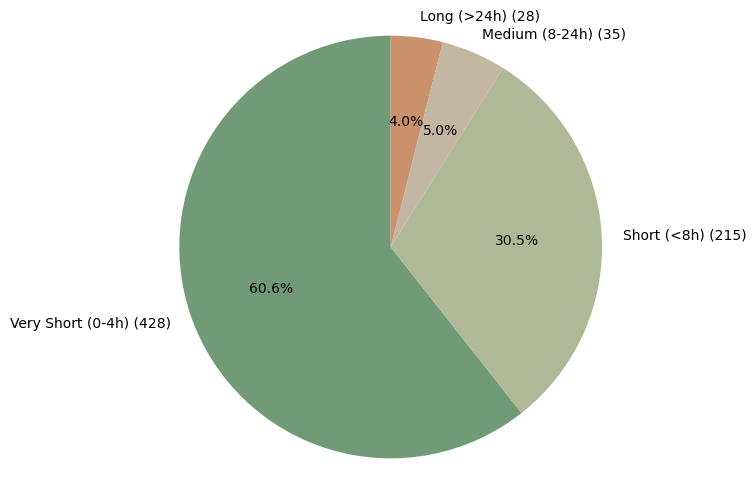

In [47]:
import matplotlib.pyplot as plt

counts = df['Absenteeism_terms'].fillna('Missing').value_counts(dropna=False)
labels_with_counts = [f"{lab} ({cnt})" for lab, cnt in counts.items()]

# Palette migliorata (verde, giallo, arancio, grigio)
colors = ['#719b77', "#b0b997", '#c3b7a3', '#c9916c'][:len(counts)]

plt.figure(figsize=(6,6))
plt.pie(counts, labels=labels_with_counts, autopct='%1.1f%%', startangle=90, colors=colors)
plt.axis('equal')
plt.show()


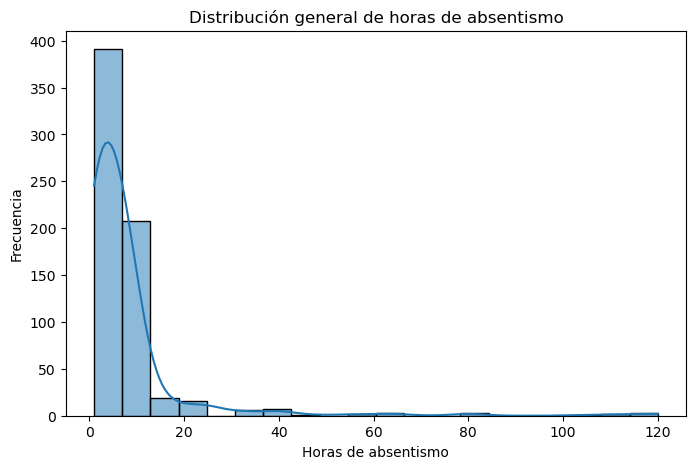

In [13]:
# Histograma de distribución general

plt.figure(figsize=(8,5))
sns.histplot(df_clean['Absenteeism_hours'], bins=20, kde=True)
plt.title('Distribución general de horas de absentismo')
plt.xlabel('Horas de absentismo')
plt.ylabel('Frecuencia')
plt.show()

Media inflada por casos extremos (120 h) - mean 7.6h y median 4h
Gran dispersion por presencia de casos extremos

Magnitud moderada en  promedio 7.6h pero altamente desigual: mediana de 4h y 75% con menos de 8h
Outliers incrementan la media y explica alta variabilidad.
Los percentiles son más adecuados para describir el comportamiento típico del absentísmo y no la media 

### Visualizar patrones temporales

Identificar meses criticos, estacionalidad y variabilidad

In [14]:
# Agrupación por mes

df_month = df_clean.groupby('Month_absence')['Absenteeism_hours'].agg(
    total_absence='sum',
    mean_absence='mean',
    median_absence='median',
    count='count'
).reset_index()

df_month


,Month_absence,total_absence,mean_absence,median_absence,count
0,1,212,4.818182,2.0,44
1,2,269,4.338710,3.0,62
2,3,755,9.556962,4.0,79
3,4,476,9.714286,4.0,49
4,5,393,7.145455,3.0,55
5,6,411,8.058824,4.0,51
6,7,730,11.587302,8.0,63
7,8,288,5.333333,4.0,54
8,9,291,6.767442,3.0,43
9,10,344,5.733333,3.0,60


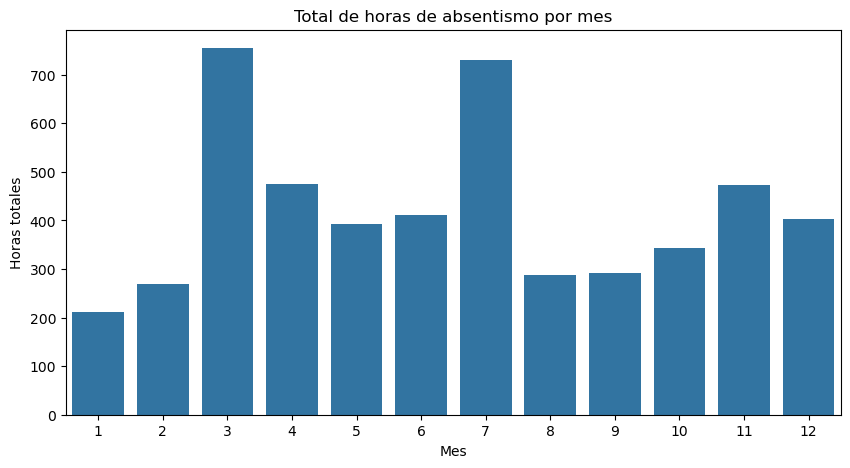

In [15]:
# Gráfico de barras: total de horas por mes (meses criticos)

plt.figure(figsize=(10,5))
sns.barplot(data=df_month,x='Month_absence', y='total_absence')
plt.title('Total de horas de absentismo por mes')
plt.xlabel('Mes')
plt.ylabel('Horas totales')
plt.show()

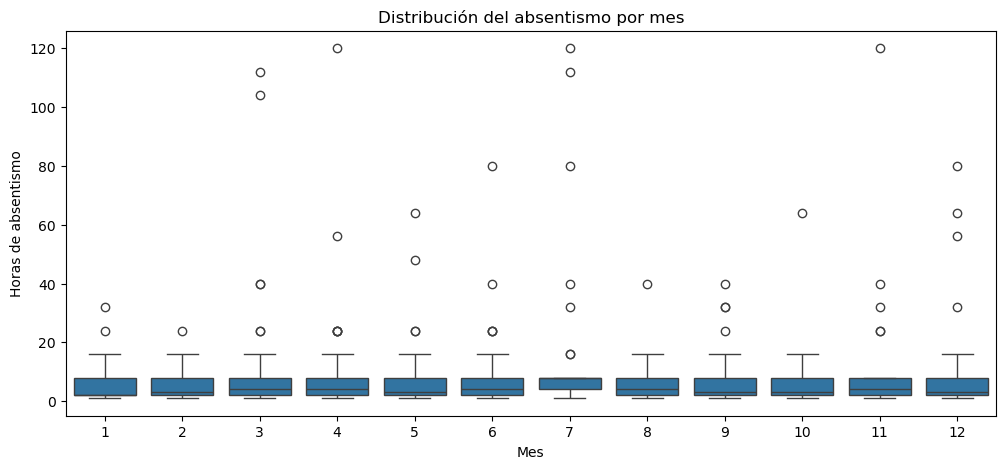

In [16]:
# boxplot por mes para ver dispersion y outliers (variabilidad)

plt.figure(figsize=(12,5))
sns.boxplot(data=df_clean, x='Month_absence', y='Absenteeism_hours')
plt.title('Distribución del absentismo por mes')
plt.xlabel('Mes')
plt.ylabel('Horas de absentismo')
plt.show()

### Variación estacional

In [17]:
# Grafico por estacion - (estacionalidad)

# Agrupación por estación
df_season = df_clean.groupby('Seasons')['Absenteeism_hours'].agg(
    total_absence='sum',
    mean_absence='mean',
    median_absence='median',
    count='count'
).reset_index()

df_season

,Seasons,total_absence,mean_absence,median_absence,count
0,autumn,1107,6.511765,3.0,170
1,spring,1221,7.267857,3.0,168
2,summer,1236,7.677019,4.0,161
3,winter,1479,9.073620,4.0,163


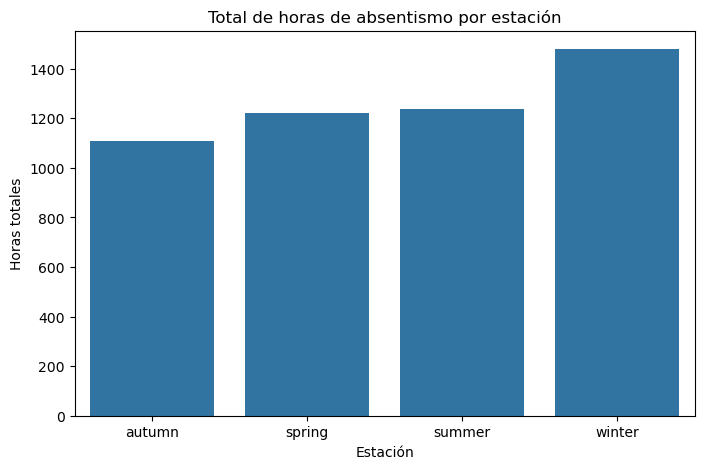

In [18]:
# Gráfico comparativo por estación

plt.figure(figsize=(8,5))
sns.barplot(data=df_season, x='Seasons', y='total_absence')
plt.title('Total de horas de absentismo por estación')
plt.xlabel('Estación')
plt.ylabel('Horas totales')
plt.show()

Más riesgo de ausencias prolongadas en invierno, verano y primavera con niveles similares 

### Perfiles de riesgo asociados al tiempo

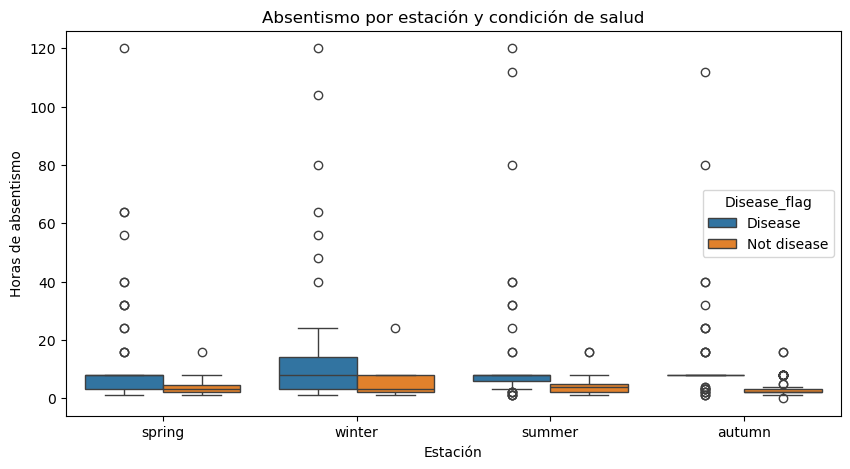

In [19]:
# Comparación de absentismo por estación y presencia de enfermedad

plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='Seasons', y='Absenteeism_hours', hue='Disease_flag')
plt.title('Absentismo por estación y condición de salud')
plt.xlabel('Estación')
plt.ylabel('Horas de absentismo')
plt.show()

In [20]:
# Cruzamos estación y tipo de ausencia
 
# total de horas por estación y motivo

df_cross = df_clean.groupby(['Seasons', 'Reason_absence_mapped'])['Absenteeism_hours'].sum().reset_index()
df_cross.sort_values(['Seasons', 'Absenteeism_hours'], ascending=[True, False])

,Seasons,Reason_absence_mapped,Absenteeism_hours
11,autumn,Diseases of the skin and subcutaneous tissue,155
8,autumn,Diseases of the musculoskeletal system and con...,136
18,autumn,"Symptoms, signs and abnormal clinical and labo...",131
13,autumn,"Injury, poisoning and other consequences of ex...",94
17,autumn,Physiotherapy,84
...,...,...,...
64,winter,Certain infectious and parasitic diseases,8
63,winter,Certain conditions originating in the perinata...,6
67,winter,Diseases of the ear and mastoid process,6
71,winter,Diseases of the nervous system,3


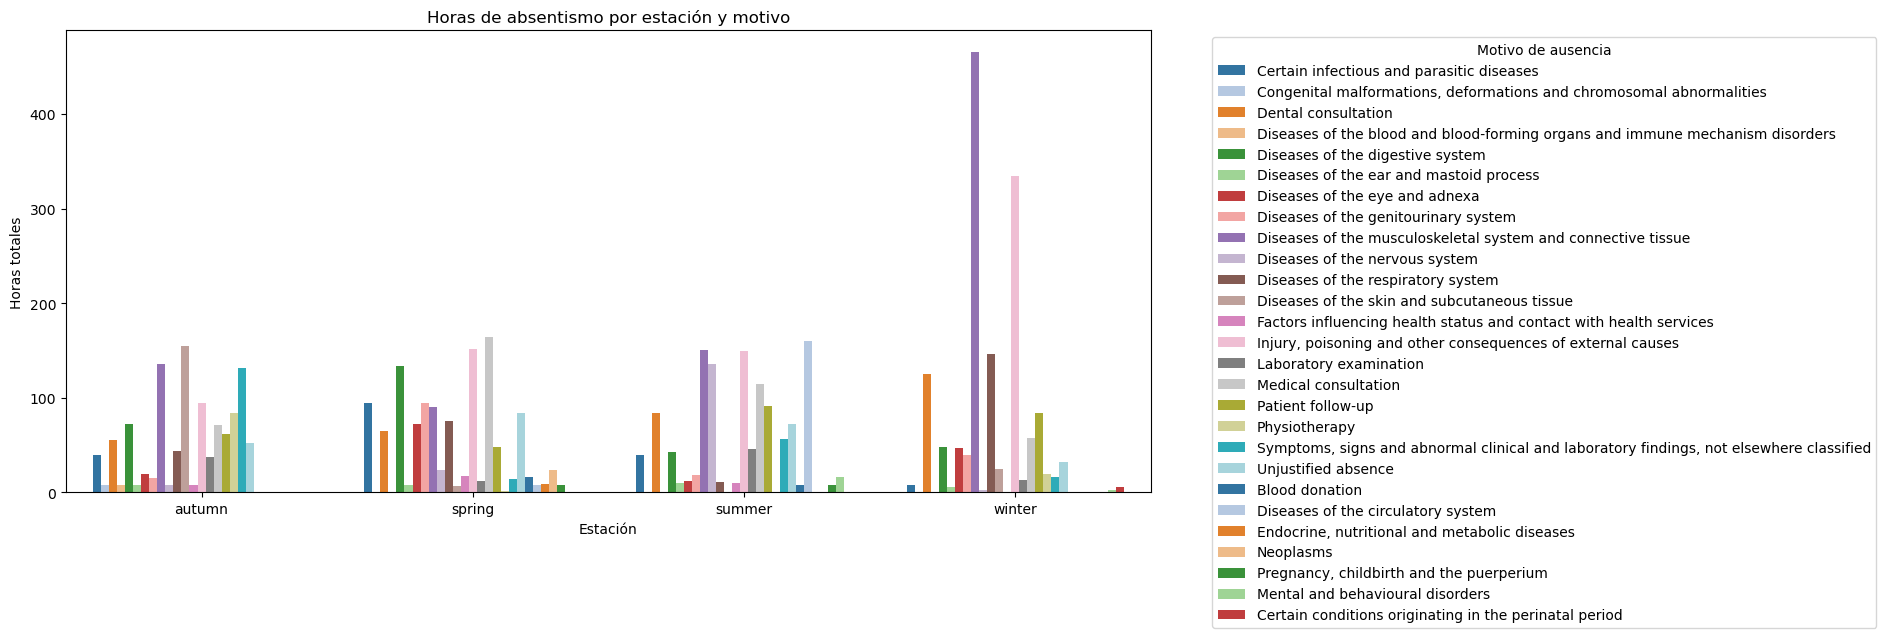

In [21]:
# visualización

plt.figure(figsize=(14,6))
sns.barplot(
    data=df_cross,
    x='Seasons',
    y='Absenteeism_hours',
    hue='Reason_absence_mapped',
    palette='tab20'
)
plt.title('Horas de absentismo por estación y motivo')
plt.xlabel('Estación')
plt.ylabel('Horas totales')
plt.legend(title='Motivo de ausencia', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [22]:
# motivos por estación

df_cross.groupby('Seasons').apply(
    lambda x: x.sort_values('Absenteeism_hours', ascending=False).head(3)
)

C:\Users\acaro\AppData\Local\Temp\ipykernel_29616\455762925.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_cross.groupby('Seasons').apply(


Seasons                              Reason_absence_mapped  \
Seasons                                                                 
autumn  11  autumn       Diseases of the skin and subcutaneous tissue   
        8   autumn  Diseases of the musculoskeletal system and con...   
        18  autumn  Symptoms, signs and abnormal clinical and labo...   
spring  36  spring                               Medical consultation   
        34  spring  Injury, poisoning and other consequences of ex...   
        24  spring                   Diseases of the digestive system   
summer  46  summer                 Diseases of the circulatory system   
        51  summer  Diseases of the musculoskeletal system and con...   
        55  summer  Injury, poisoning and other consequences of ex...   
winter  70  winter  Diseases of the musculoskeletal system and con...   
        74  winter  Injury, poisoning and other consequences of ex...   
        72  winter                 Diseases of the respiratory system   

            Absenteeism_hours  
Seasons                        
autumn  11                155  
        8                 136  
        18                131  
spring  36                164  
        34                152  
        24                134  
summer  46                160  
        51                151  
        55                149  
winter  70                465  
        74                334  
        72                146

### Identificación meses críticos

In [23]:
# Top 3 meses con mayor absentismo total

df_month.sort_values('total_absence', ascending=False).head(3)

,Month_absence,total_absence,mean_absence,median_absence,count
2,3,755,9.556962,4.0,79
6,7,730,11.587302,8.0,63
3,4,476,9.714286,4.0,49


In [24]:
# Top 3 meses con mayor absentismo promedio

df_month.sort_values('mean_absence', ascending=False).head(3)

,Month_absence,total_absence,mean_absence,median_absence,count
6,7,730,11.587302,8.0,63
3,4,476,9.714286,4.0,49
2,3,755,9.556962,4.0,79


### Conclusiones

In [25]:
print("Mes con mayor absentismo total:", 
      df_month.loc[df_month['total_absence'].idxmax(), 'Month_absence'])

print("Estación con mayor absentismo total:", 
      df_season.loc[df_season['total_absence'].idxmax(), 'Seasons'])

Mes con mayor absentismo total: 3
Estación con mayor absentismo total: winter
